# Notebook 6: Entanglement & Bell Inequality Violation

## What are we exploring?

This notebook tackles a central question in quantum foundations: **can quantum
correlations be explained by local hidden variables satisfying the CHSH assumptions?**

We will:
1. Construct a two-mode squeezed vacuum as the number-basis output of PDC
2. Construct all four polarization Bell states
3. Verify their entanglement using concurrence and von Neumann entropy
4. Implement the CHSH inequality test
5. Show that $S = 2\sqrt{2} > 2$, **violating** the classical bound

## Tensor products and correlations

Bell tests use tensor-product structure, local measurement operators, and
correlation functions. The physical result is that entangled photon correlations
cannot be explained by local hidden-variable/local-realist models satisfying the
CHSH assumptions, while still respecting no-signaling.

## Conventions used in this notebook

- Polarization qubits use $|H\rangle=|0\rangle$ and $|V\rangle=|1\rangle$.
- Analyzer angles are physical polarization angles, so observables use $\cos(2\phi)$ and $\sin(2\phi)$.
- The two-mode squeeze convention is $S_2(\xi)=\exp(\xi^*a_1a_2-\xi a_1^\dagger a_2^\dagger)$.
- QuTiP's `squeezing(a1, a2, z)` helper has a `1/2` in the exponent; match with `z=2*xi`.


## Setup

In [1]:
from pathlib import Path
import sys

import numpy as np
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import qutip

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
FIG_DIR = PROJECT_ROOT / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

plt.rcParams.update({
    'font.size': 12, 'axes.labelsize': 14, 'axes.titlesize': 16,
    'figure.figsize': (8, 5), 'figure.dpi': 150, 'savefig.dpi': 300,
    'text.usetex': False, 'mathtext.fontset': 'stix', 'font.family': 'STIXGeneral',
})

# Pauli matrices
sx = qutip.sigmax()
sy = qutip.sigmay()
sz = qutip.sigmaz()


def sigma_pol(phi):
    """Polarization analyzer at physical angle phi.
    The corresponding Bloch-sphere angle is 2*phi.
    """
    return np.cos(2*phi) * sz + np.sin(2*phi) * sx


print("Setup complete.")

Setup complete.


## Two-Mode Squeezed Vacuum

Type-I parametric down-conversion at higher gain produces a two-mode squeezed
vacuum:

$$|\mathrm{TMSV}\rangle = \hat{S}_2(\xi)|0,0\rangle
= \frac{1}{\cosh r}\sum_{n=0}^{\infty}(-e^{i\phi_{\rm squeeze}}\tanh r)^n |n,n\rangle.$$

The key signature is perfect photon-number correlation: the two modes contain
the same photon number in every occupied Fock component.

TMSV reduced-state entropy: 1.2180 bits
TMSV mean photon pairs: 0.4053
TMSV analytic omitted tail P(n >= 12): 3.31e-07


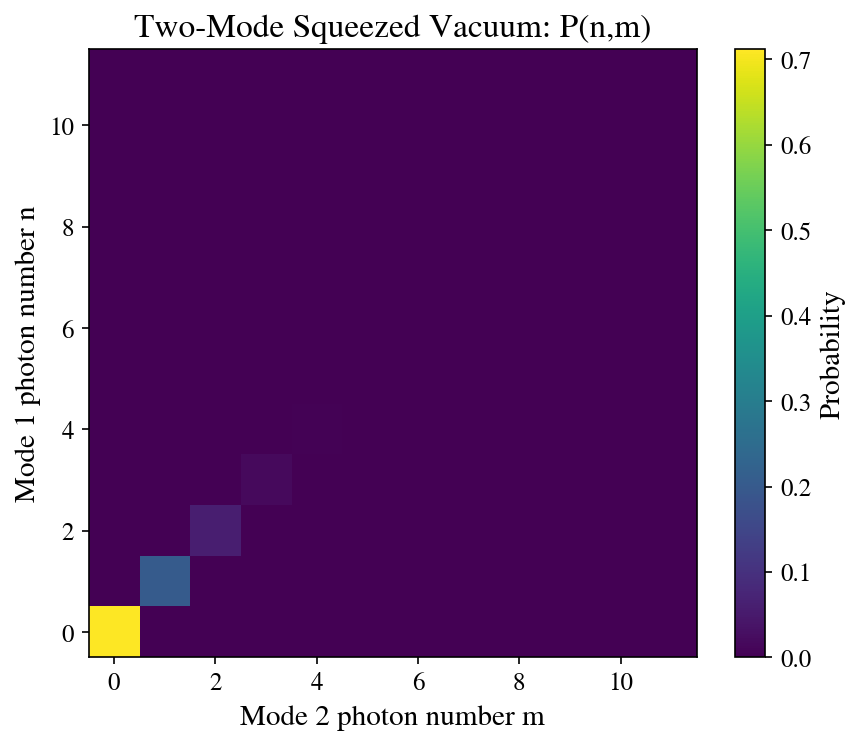


[PASS] TMSV: probability concentrated on |n,n> pairs only


In [2]:
def two_mode_squeezed_vacuum(N, r, phase=0.0):
    """Construct |TMSV> with P(n,n) = (1-lambda)*lambda**n.

    Convention:
        S2(xi) = exp[xi* a1 a2 - xi a1.dag() a2.dag()]
        lambda = tanh(r)**2
    """
    a1_fock = qutip.tensor(qutip.destroy(N), qutip.qeye(N))
    a2_fock = qutip.tensor(qutip.qeye(N), qutip.destroy(N))
    xi = r * np.exp(1j * phase)
    G = np.conj(xi) * a1_fock * a2_fock - xi * a1_fock.dag() * a2_fock.dag()
    vac2 = qutip.tensor(qutip.basis(N, 0), qutip.basis(N, 0))
    return (G.expm() * vac2).unit()


def tmsv_tail(N, r):
    """Analytic omitted probability P(n >= N) for TMSV number-pair distribution."""
    lam = np.tanh(r) ** 2
    return float(lam ** N)


N_tmsv = 12
r_tmsv = 0.6
assert tmsv_tail(N_tmsv, r_tmsv) < 1e-6, "Increase N_tmsv"
tmsv = two_mode_squeezed_vacuum(N_tmsv, r_tmsv)
assert np.isclose(tmsv.norm(), 1.0, atol=1e-12), "TMSV not normalized"

rho_mode1 = tmsv.ptrace(0)
entropy_tmsv = qutip.entropy_vn(rho_mode1, base=2)
mean_pair_number = np.sinh(r_tmsv) ** 2
tail_pair = tmsv_tail(N_tmsv, r_tmsv)
print(f"TMSV reduced-state entropy: {entropy_tmsv:.4f} bits")
print(f"TMSV mean photon pairs: {mean_pair_number:.4f}")
print(f"TMSV analytic omitted tail P(n >= {N_tmsv}): {tail_pair:.2e}")

# Photon-number correlation heatmap
P_nm = np.zeros((N_tmsv, N_tmsv))
for n in range(N_tmsv):
    for m in range(N_tmsv):
        proj = qutip.tensor(qutip.basis(N_tmsv, n), qutip.basis(N_tmsv, m))
        P_nm[n, m] = abs(proj.overlap(tmsv))**2

assert np.isclose(P_nm.sum(), 1.0, atol=1e-10), "TMSV P(n,m) not normalized"
off_diagonal = P_nm.copy()
np.fill_diagonal(off_diagonal, 0.0)
assert off_diagonal.sum() < 1e-10, "TMSV should only have P on |n,n> pairs"

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(P_nm, origin='lower', cmap='viridis')
ax.set_xlabel('Mode 2 photon number m')
ax.set_ylabel('Mode 1 photon number n')
ax.set_title('Two-Mode Squeezed Vacuum: P(n,m)')
plt.colorbar(im, ax=ax, label='Probability')
plt.tight_layout()
plt.savefig(FIG_DIR / 'tmsv_photon_correlations.png', bbox_inches='tight', dpi=300)
plt.savefig(FIG_DIR / 'tmsv_photon_correlations.svg', bbox_inches='tight')
plt.show()

print("\n[PASS] TMSV: probability concentrated on |n,n> pairs only")

## The Four Bell States

The four maximally entangled two-qubit states form a complete orthonormal basis
for the two-qubit Hilbert space:

| State | Definition |
|-------|-----------|
| $|\Phi^+\rangle$ | $(|00\rangle + |11\rangle)/\sqrt{2}$ |
| $|\Phi^-\rangle$ | $(|00\rangle - |11\rangle)/\sqrt{2}$ |
| $|\Psi^+\rangle$ | $(|01\rangle + |10\rangle)/\sqrt{2}$ |
| $|\Psi^-\rangle$ | $(|01\rangle - |10\rangle)/\sqrt{2}$ |

In [3]:
ket0 = qutip.basis(2, 0)  # |H>
ket1 = qutip.basis(2, 1)  # |V>

phi_plus  = (qutip.tensor(ket0, ket0) + qutip.tensor(ket1, ket1)).unit()
phi_minus = (qutip.tensor(ket0, ket0) - qutip.tensor(ket1, ket1)).unit()
psi_plus  = (qutip.tensor(ket0, ket1) + qutip.tensor(ket1, ket0)).unit()
psi_minus = (qutip.tensor(ket0, ket1) - qutip.tensor(ket1, ket0)).unit()

bell_states = {
    '|Phi+>': phi_plus,
    '|Phi->': phi_minus,
    '|Psi+>': psi_plus,
    '|Psi->': psi_minus,
}

print("=== Bell State Orthonormality ===\n")
for n1, s1 in bell_states.items():
    for n2, s2 in bell_states.items():
        overlap = abs(s1.overlap(s2))**2
        if overlap > 0.01:
            print(f"<{n1}|{n2}>^2 = {overlap:.1f}")

=== Bell State Orthonormality ===

<|Phi+>||Phi+>>^2 = 1.0
<|Phi->||Phi->>^2 = 1.0
<|Psi+>||Psi+>>^2 = 1.0
<|Psi->||Psi->>^2 = 1.0
